# Exercise 7

Text Generation using LSTM

In [1]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import tensorflow.keras.utils as ku
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, LayerNormalization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tokenizer = Tokenizer()

!wget --no-check-certificate \
    https://raw.githubusercontent.com/cibernox/storyteller/refs/heads/master/snow-white.txt \
    -O /tmp/snowwhite.txt

data = open('/tmp/snowwhite.txt').read()

--2025-05-27 09:26:39--  https://raw.githubusercontent.com/cibernox/storyteller/refs/heads/master/snow-white.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1520 (1.5K) [text/plain]
Saving to: ‘/tmp/snowwhite.txt’

/tmp/snowwhite.txt  100%[===================>]   1.48K  --.-KB/s    in 0s      

2025-05-27 09:26:39 (23.7 MB/s) - ‘/tmp/snowwhite.txt’ saved [1520/1520]



In [3]:
corpus = data.lower().split("\n")

tokenizer.fit_on_texts(corpus)
total_words = len(tokenizer.word_index) + 1

input_sequences = []
for line in corpus:
	token_list = tokenizer.texts_to_sequences([line])[0]
	for i in range(1, len(token_list)):
		n_gram_sequence = token_list[:i+1]
		input_sequences.append(n_gram_sequence)

max_sequence_len = max([len(x) for x in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

predictors, label = input_sequences[:,:-1],input_sequences[:,-1]

label = ku.to_categorical(label, num_classes=total_words)

## Create the LSTM model

1. Build an LSTM

In [4]:
model = Sequential()
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(Bidirectional(LSTM(256, return_sequences=True, recurrent_dropout=0.2)))
model.add(LayerNormalization())
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(128)))
model.add(Dense(256, activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)))
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu', kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4)))
model.add(Dropout(0.3))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [5]:
history = model.fit(predictors, label, epochs=70, verbose=1, batch_size=64)

Epoch 1/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 73ms/step - accuracy: 0.0123 - loss: 5.1808
Epoch 2/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.0244 - loss: 5.1165
Epoch 3/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.0687 - loss: 4.9773
Epoch 4/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0583 - loss: 4.9724
Epoch 5/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0767 - loss: 4.8214
Epoch 6/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0595 - loss: 4.8872
Epoch 7/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.0790 - loss: 4.8066
Epoch 8/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.0862 - loss: 4.6748
Epoch 9/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.0768 - loss: 4.6763
Epoch 10/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0889 - loss: 4.5767
Epoch 11/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0586 - loss: 4.5779
Epoch 12/70
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.0915 - loss: 4.4085


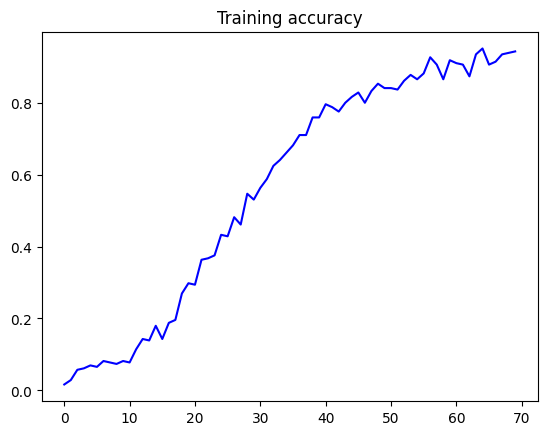

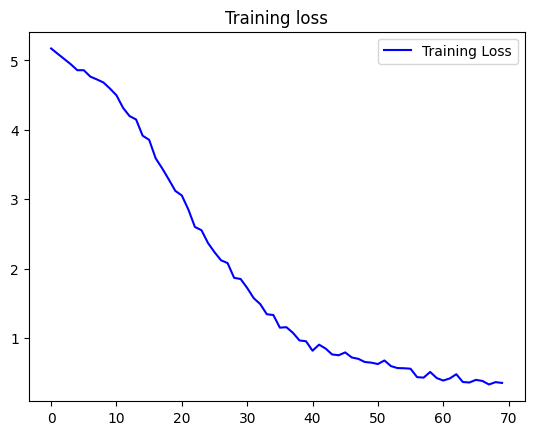

In [6]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.title('Training accuracy')

plt.figure()

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.title('Training loss')
plt.legend()

plt.show()

## B. Generate texts


In [7]:
def generate_text(seed_text, next_words=40, temperature=0.5):
    output = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([output])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        preds = model.predict(token_list, verbose=0)[0]
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)
        predicted = np.random.choice(len(preds), p=preds)
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        if output_word == "":
            break
        output += " " + output_word
    return output

2. "Snow White lived in the forest with..."

In [13]:
seed_text = "Snow White lived in the forest with"
print(generate_text(seed_text, next_words=100, temperature=15))

Snow White lived in the forest with long beautiful white failed greedy thought fatal was deed majesty eyes away she every contented far sounds mumbled fatal in until majesty the courage sounds rich your agreed you sitting this heard failed in the forest he courage last away woman man's so castle reward the happy until of unseen magic great ran they put death your so white take furious loveliest pretty thump ran asked far told eyes dreadful an spying very return fatal fatal delicate too all strange happy dreadful jealous majesty blue failed rid could fair came girl forest everyone off however he furious wall thump to


3. "The queen looked into the mirror and said..."

In [15]:
seed_text = "The queen looked into the mirror and said"
print(generate_text(seed_text, next_words=100, temperature=18))

The queen looked into the mirror and said servant began snow quite that wild but thought quite at and not from return land came alone prince's at mumbled rich dreadful innocent woman of all whenever a sure overcome far began under jealousy the white intc is him become fair take under whenever who


4. "One day, Snow White found a small cottage and..."

In [10]:
seed_text = "One day, Snow White found a small cottage and"
print(generate_text(seed_text, next_words=100, temperature=5))

One day, Snow White found a small cottage and strange get failed servants feel but last rival began mirror failed on calling reward the innocent eyes came courage and contented long ran then contented tree wild agreed long contented innocent intc leaving sounds excuse bribed trusty the off reward unseen hair of very with servants from bitterly far of snow led was take bribed all servant rid white asked mumbled all night trusty excuse skin hair so this came strange him day up strange at then return excuse majesty failed and unseen so with jealous terrible sounds fatal loveliest return very rid told the one furious wicked but night


In [26]:
seed_text = "snow white ate a poisonous"
print(generate_text(seed_text, next_words=5, temperature=8))

snow white ate a poisonous mirror fatal long time woman


In [28]:
seed_text = "Snow white is"
print(generate_text(seed_text, next_words=5, temperature=0.5))

Snow white is the loveliest in the land
